# Tag 1, Run 1 — Kandidatenvergleich: Myopic Centrality vs. CFA-Future Centrality

**Kernfrage:** Sind die Kandidaten für den Initialplan bei beiden Modellen an Tag 1 identisch?

Beide Modelle verwenden `zone_selection_mode: centrality` → rein geometrisches Zonen-Scoring (mittlere Distanz zu anderen Zentroiden). Da Seed, n_zones und der Anfangszustand (alle Stationen bei dsm=365, kein Carryover) gleich sind, **müssen** die Kandidaten gleich sein. Die Routen-Reihenfolge unterscheidet sich jedoch, weil Myopic und CFA-Future unterschiedliche Insertion-Costs verwenden.

In [56]:
import json
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

ROOT = Path('/home/philipphuemmer/workspace/masterarbeit')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print(f"Projektroot: {ROOT}")

from src.data.loader import load_stations, get_coordinates
import yaml

with open(ROOT / 'configs/config.yaml') as f:
    cfg = yaml.safe_load(f)

df = load_stations(cfg)
all_coords = np.array(get_coordinates(df, cfg))  # shape (398, 2): Index 0 = Depot
depot_coord = all_coords[0]
print(f"Stationen: {len(df)}, Koordinaten inkl. Depot: {len(all_coords)}")
print(f"Depot: {depot_coord}")

Projektroot: /home/philipphuemmer/workspace/masterarbeit
Stationen: 397, Koordinaten inkl. Depot: 398
Depot: [49.776414  9.938582]


In [57]:
# Lädt Run 1 für beide Modelle
with open('logs/myopic_centrality/json/run_1.json') as f:
    myopic = json.load(f)
with open('logs/cfa_future_centrality/json/run_1.json') as f:
    cfa = json.load(f)

# Hour 8, Day 1 = Initialplan-Eintrag
mh1 = myopic['hourly'][0]
ch1 = cfa['hourly'][0]

assert mh1['day'] == 1 and mh1['hour'] == 8
assert ch1['day'] == 1 and ch1['hour'] == 8
print("Stunde/Tag korrekt geladen: Day 1, Hour 8")

Stunde/Tag korrekt geladen: Day 1, Hour 8


In [58]:
# ── Kandidaten extrahieren ──────────────────────────────────────────────────
def get_candidates(hourly_entry):
    tasks = hourly_entry['solver_debug']['input']['tasks_per_team']
    return {int(team): [t['node_idx'] for t in task_list] for team, task_list in tasks.items()}

mc = get_candidates(mh1)
cc = get_candidates(ch1)

print("MYOPIC Kandidaten:")
for t, nodes in mc.items():
    print(f"  Team {t}: {nodes}")
print()
print("CFA-FUTURE Kandidaten:")
for t, nodes in cc.items():
    print(f"  Team {t}: {nodes}")
print()
print("Kandidaten identisch?", mc == cc)

MYOPIC Kandidaten:
  Team 0: [30, 31, 36, 37, 38, 32, 26, 59, 201, 203]
  Team 1: [45, 46, 48, 13, 23, 24, 3, 8, 11, 12]

CFA-FUTURE Kandidaten:
  Team 0: [30, 31, 36, 37, 38, 32, 26, 59, 201, 203]
  Team 1: [45, 46, 48, 13, 23, 24, 3, 8, 11, 12]

Kandidaten identisch? True


In [59]:
# ── Routen extrahieren ─────────────────────────────────────────────────────
def get_route(initial_plan, team_id):
    """Gibt Liste von Stop-Dicts zurück; überspringt Einträge ohne node_idx (z.B. Mittagspause)."""
    for entry in initial_plan:
        if entry['team_id'] == team_id:
            return [
                {
                    'node_idx': s['node_idx'],
                    'arrival': s['arrival_time'],
                    'departure': s['departure_time'],
                    'travel_km': s.get('travel_km', 0),
                    'travel_min': s.get('travel_time_min', 0),
                    'dsm': s.get('days_since_maintenance', None),
                    'task_type': s.get('task_type', 'routine'),
                }
                for s in entry['route']
                if 'node_idx' in s  # Mittagspause / interne Events ausschließen
            ]
    return []

mr0 = get_route(mh1['initial_plan'], 0)
mr1 = get_route(mh1['initial_plan'], 1)
cr0 = get_route(ch1['initial_plan'], 0)
cr1 = get_route(ch1['initial_plan'], 1)

print(f"Myopic  | Team 0: {len(mr0)} Stops | Team 1: {len(mr1)} Stops")
print(f"CFA-Fut | Team 0: {len(cr0)} Stops | Team 1: {len(cr1)} Stops")
print()
print("Myopic  Team 0 Route:", [s['node_idx'] for s in mr0])
print("CFA-Fut Team 0 Route:", [s['node_idx'] for s in cr0])
print()
print("Myopic  Team 1 Route:", [s['node_idx'] for s in mr1])
print("CFA-Fut Team 1 Route:", [s['node_idx'] for s in cr1])

Myopic  | Team 0: 10 Stops | Team 1: 10 Stops
CFA-Fut | Team 0: 10 Stops | Team 1: 9 Stops

Myopic  Team 0 Route: [36, 30, 31, 26, 37, 38, 32, 59, 201, 203]
CFA-Fut Team 0 Route: [36, 30, 31, 59, 201, 203, 32, 26, 37, 38]

Myopic  Team 1 Route: [45, 46, 48, 11, 12, 13, 24, 23, 8, 3]
CFA-Fut Team 1 Route: [45, 46, 48, 13, 11, 12, 8, 3, 24]


## Visualisierung 1 — Kandidaten & Routen auf der Karte (Tag 1)

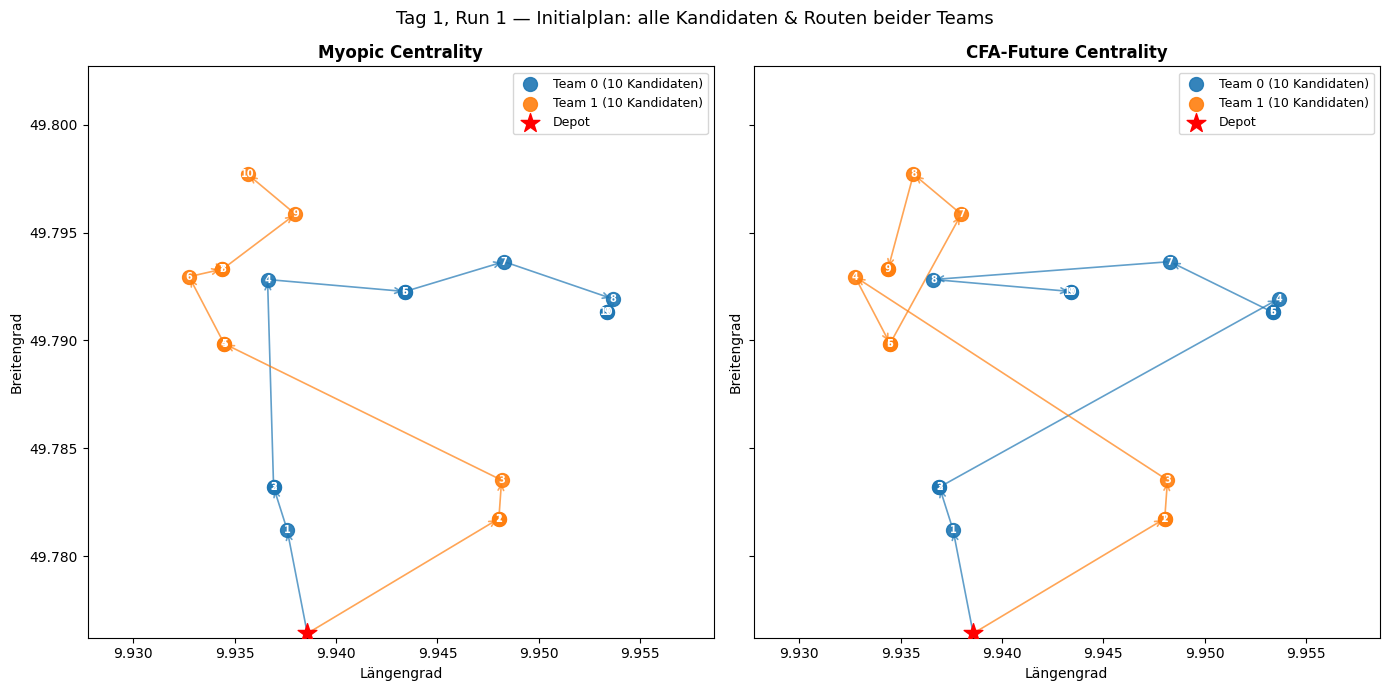

In [60]:
TEAM_COLORS = ['#1f77b4', '#ff7f0e']  # blau = Team 0, orange = Team 1
MARGIN = 0.005

# Zoom auf alle Kandidaten beider Teams
all_cand_nodes = set(n for t in mc.values() for n in t) | set(n for t in cc.values() for n in t)
all_cand_coords = np.array([all_coords[n] for n in all_cand_nodes])
lat_min = all_cand_coords[:, 0].min() - MARGIN
lat_max = all_cand_coords[:, 0].max() + MARGIN
lon_min = all_cand_coords[:, 1].min() - MARGIN
lon_max = all_cand_coords[:, 1].max() + MARGIN

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)

for ax, (model_name, candidates, routes) in zip(axes, [
    ('Myopic Centrality', mc, [mr0, mr1]),
    ('CFA-Future Centrality', cc, [cr0, cr1]),
]):
    for tid, (color, route) in enumerate(zip(TEAM_COLORS, routes)):
        cand_nodes = candidates[tid]
        cand_coords = np.array([all_coords[n] for n in cand_nodes])

        # Kandidaten-Punkte
        ax.scatter(cand_coords[:, 1], cand_coords[:, 0],
                   s=100, color=color, zorder=3, alpha=0.9,
                   label=f'Team {tid} ({len(cand_nodes)} Kandidaten)')

        # Routen-Pfeile
        route_nodes = [0] + [s['node_idx'] for s in route]
        for i in range(len(route_nodes) - 1):
            a = all_coords[route_nodes[i]]
            b = all_coords[route_nodes[i + 1]]
            a_vis = lat_min <= a[0] <= lat_max and lon_min <= a[1] <= lon_max
            b_vis = lat_min <= b[0] <= lat_max and lon_min <= b[1] <= lon_max
            if a_vis or b_vis:
                ax.annotate('', xy=(b[1], b[0]), xytext=(a[1], a[0]),
                            arrowprops=dict(arrowstyle='->', color=color,
                                            lw=1.2, alpha=0.7),
                            zorder=2)

        # Schritt-Nummern
        for step, s in enumerate(route, start=1):
            coord = all_coords[s['node_idx']]
            ax.annotate(str(step), xy=(coord[1], coord[0]),
                        fontsize=7, ha='center', va='center',
                        color='white', fontweight='bold', zorder=5)

    # Depot
    if lat_min <= depot_coord[0] <= lat_max and lon_min <= depot_coord[1] <= lon_max:
        ax.scatter(depot_coord[1], depot_coord[0],
                   s=200, marker='*', color='red', zorder=4, label='Depot')

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Längengrad')
    ax.set_ylabel('Breitengrad')
    ax.legend(fontsize=9)

fig.suptitle('Tag 1, Run 1 — Initialplan: alle Kandidaten & Routen beider Teams', fontsize=13)
plt.tight_layout()
plt.show()

## Visualisierung 2 — Routen-Reihenfolge (Gantt-Diagramm Tag 1)

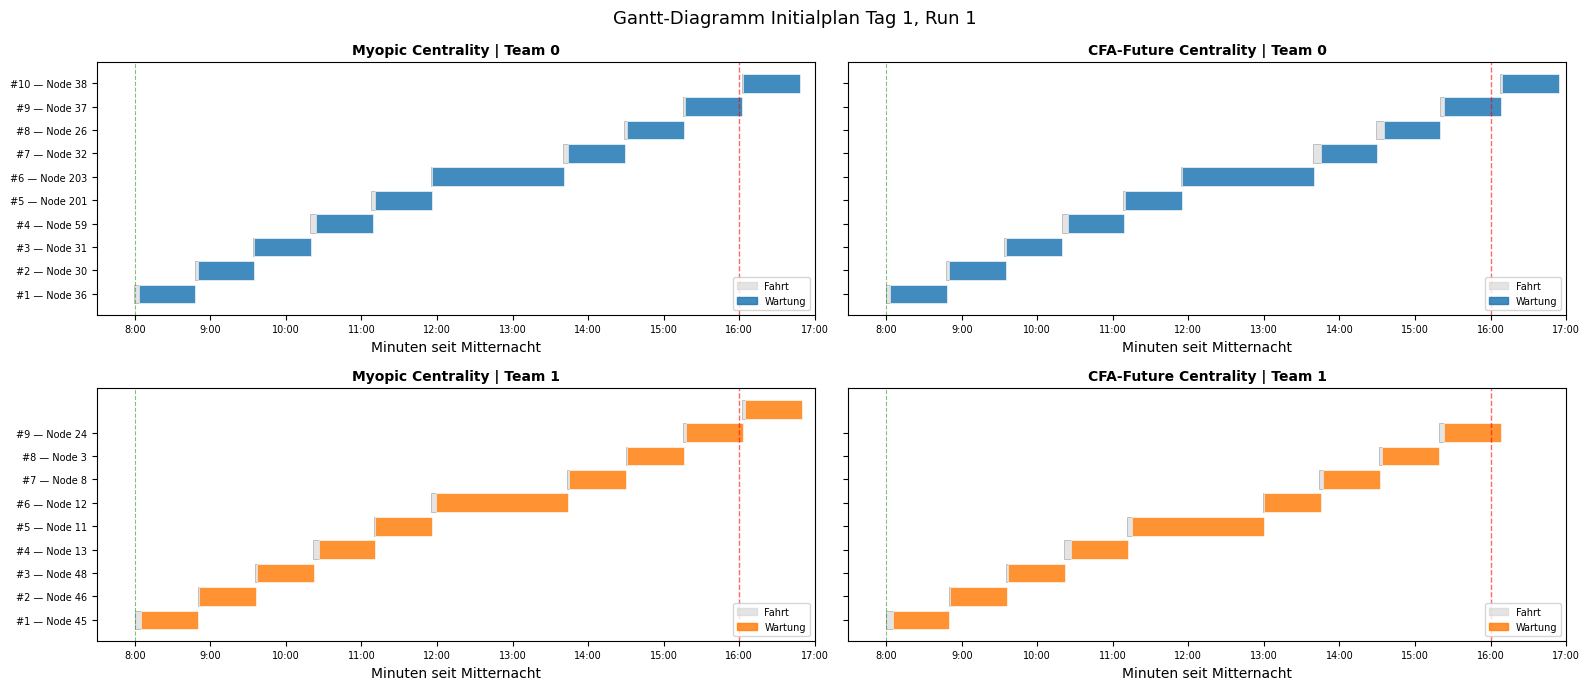

In [61]:
def parse_hhmm(s):
    """'08:03' → Minuten seit Mitternacht."""
    h, m = s.split(':')
    return int(h) * 60 + int(m)

def build_gantt_df(route_t0, route_t1, label):
    rows = []
    for tid, route in enumerate([route_t0, route_t1]):
        for step, s in enumerate(route, start=1):
            arr = parse_hhmm(s['arrival'])
            dep = parse_hhmm(s['departure'])
            rows.append({
                'model': label,
                'team': tid,
                'step': step,
                'node': s['node_idx'],
                'start': arr,
                'end': dep,
                'service': dep - arr,
                'travel_min': s['travel_min'],
            })
    return pd.DataFrame(rows)

dm = build_gantt_df(mr0, mr1, 'Myopic')
dc = build_gantt_df(cr0, cr1, 'CFA-Future')

fig, axes = plt.subplots(2, 2, figsize=(16, 7), sharey='row')

for col, (df_g, model_name) in enumerate([(dm, 'Myopic Centrality'), (dc, 'CFA-Future Centrality')]):
    for row, tid in enumerate([0, 1]):
        ax = axes[row][col]
        team_df = df_g[df_g['team'] == tid].reset_index(drop=True)
        color = TEAM_COLORS[tid]

        yticks, yticklabels = [], []
        for i, r in team_df.iterrows():
            # Fahrt (hellgrau)
            travel_start = r['start'] - r['travel_min']
            ax.barh(i, r['travel_min'], left=travel_start,
                    color='lightgray', edgecolor='gray', linewidth=0.5, alpha=0.6)
            # Service (farbig)
            ax.barh(i, r['service'], left=r['start'],
                    color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
            yticks.append(i)
            yticklabels.append(f"#{r['step']} — Node {r['node']}")

        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, fontsize=7)
        ax.set_xlabel('Minuten seit Mitternacht')
        ax.axvline(16 * 60, color='red', linestyle='--', lw=1, alpha=0.6, label='16:00 Uhr')
        ax.axvline(8 * 60, color='green', linestyle='--', lw=0.8, alpha=0.5)
        ax.set_xlim(7.5 * 60, 17 * 60)
        ax.set_xticks(range(8 * 60, 17 * 60 + 1, 60))
        ax.set_xticklabels([f"{h}:00" for h in range(8, 18)], fontsize=7)
        ax.set_title(f"{model_name} | Team {tid}", fontsize=10, fontweight='bold')

        travel_patch = mpatches.Patch(color='lightgray', alpha=0.6, label='Fahrt')
        service_patch = mpatches.Patch(color=color, alpha=0.85, label='Wartung')
        ax.legend(handles=[travel_patch, service_patch], loc='lower right', fontsize=7)

fig.suptitle('Gantt-Diagramm Initialplan Tag 1, Run 1', fontsize=13)
plt.tight_layout()
plt.show()

## Visualisierung 3 — Tag-1-Metriken im Vergleich

In [62]:
md1 = myopic['days'][0]
cd1 = cfa['days'][0]

metrics = {
    'operational_cost_eur': 'Betriebskosten (€)',
    'wage_cost_eur': 'Lohnkosten (€)',
    'fuel_cost_eur': 'Fahrtkosten (€)',
    'downtime_cost_eur': 'Ausfallkosten (€)',
    'total_cost_eur': 'Gesamtkosten (€)',
    'n_routine_tasks': 'Routineaufgaben',
    'n_routine_completed': 'Erledigt',
    'disruptions_handled': 'Störungen erledigt',
    'disruptions_carryover': 'Störungen Carryover',
}

rows = []
for key, label in metrics.items():
    rows.append({'Metrik': label, 'Myopic': md1[key], 'CFA-Future': cd1[key]})
comparison_df = pd.DataFrame(rows).set_index('Metrik')
comparison_df['Δ (CFA-Future − Myopic)'] = comparison_df['CFA-Future'] - comparison_df['Myopic']
comparison_df['Δ%'] = (comparison_df['Δ (CFA-Future − Myopic)'] / comparison_df['Myopic'].replace(0, np.nan) * 100).round(1)
print(comparison_df.round(2).to_string())

                     Myopic  CFA-Future  Δ (CFA-Future − Myopic)    Δ%
Metrik                                                                
Betriebskosten (€)   570.12      570.81                     0.69   0.1
Lohnkosten (€)       560.00      560.00                     0.00   0.0
Fahrtkosten (€)       10.12       10.81                     0.69   6.8
Ausfallkosten (€)    425.15      184.32                  -240.83 -56.6
Gesamtkosten (€)     995.27      755.13                  -240.14 -24.1
Routineaufgaben       20.00       20.00                     0.00   0.0
Erledigt              11.00       11.00                     0.00   0.0
Störungen erledigt     4.00        4.00                     0.00   0.0
Störungen Carryover    2.00        2.00                     0.00   0.0


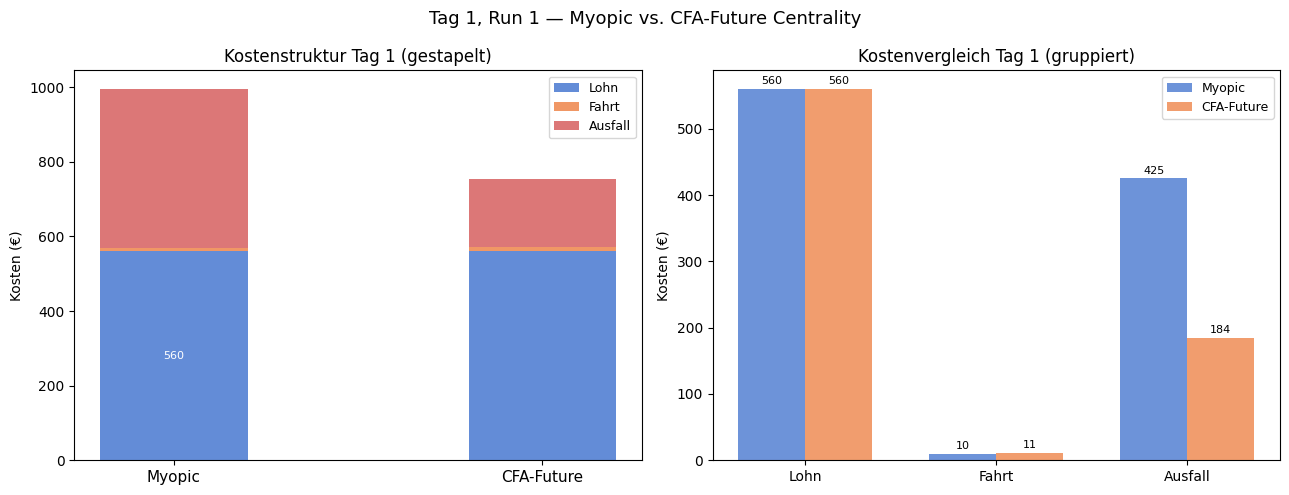


Ausfallkosten: Myopic 425.2€ vs. CFA-Future 184.3€
→ CFA-Future spart 240.8€ (57%) Ausfallkosten


In [63]:
cost_keys = ['wage_cost_eur', 'fuel_cost_eur', 'downtime_cost_eur']
cost_labels = ['Lohn', 'Fahrt', 'Ausfall']
cost_colors = ['#4878d0', '#ee854a', '#d65f5f']

myopic_vals = [md1[k] for k in cost_keys]
cfa_vals = [cd1[k] for k in cost_keys]

x = np.arange(len(cost_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gestapelter Balken
ax = axes[0]
bottom_m = bottom_c = 0
for i, (label, color, mv, cv) in enumerate(zip(cost_labels, cost_colors, myopic_vals, cfa_vals)):
    ax.bar(0, mv, bottom=bottom_m, color=color, label=label, alpha=0.85, width=0.4)
    ax.bar(1, cv, bottom=bottom_c, color=color, alpha=0.85, width=0.4)
    bottom_m += mv
    bottom_c += cv
ax.set_xticks([0, 1])
ax.set_xticklabels(['Myopic', 'CFA-Future'], fontsize=11)
ax.set_ylabel('Kosten (€)')
ax.set_title('Kostenstruktur Tag 1 (gestapelt)')
ax.legend(fontsize=9)
ax.bar_label(ax.containers[0], fmt='%.0f', label_type='center', fontsize=8, color='white')

# Gruppierten Balken (Ausfallkosten separat hervorheben)
ax2 = axes[1]
bars_m = ax2.bar(x - width/2, myopic_vals, width, label='Myopic', color='#4878d0', alpha=0.8)
bars_c = ax2.bar(x + width/2, cfa_vals, width, label='CFA-Future', color='#ee854a', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(cost_labels)
ax2.set_ylabel('Kosten (€)')
ax2.set_title('Kostenvergleich Tag 1 (gruppiert)')
ax2.legend(fontsize=9)
ax2.bar_label(bars_m, fmt='%.0f', fontsize=8, padding=2)
ax2.bar_label(bars_c, fmt='%.0f', fontsize=8, padding=2)

fig.suptitle('Tag 1, Run 1 — Myopic vs. CFA-Future Centrality', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nAusfallkosten: Myopic {md1['downtime_cost_eur']:.1f}€ vs. CFA-Future {cd1['downtime_cost_eur']:.1f}€")
print(f"→ CFA-Future spart {md1['downtime_cost_eur'] - cd1['downtime_cost_eur']:.1f}€ ({(1 - cd1['downtime_cost_eur']/md1['downtime_cost_eur'])*100:.0f}%) Ausfallkosten")

## Visualisierung 4 — Routenreihenfolge: Unterschied zwischen identischen Kandidaten

In [64]:
def route_diff_table(route_m, route_c, team_id):
    """Zeigt Positions-Unterschied zwischen Myopic und CFA-Future Reihenfolge."""
    m_order = [s['node_idx'] for s in route_m]
    c_order = [s['node_idx'] for s in route_c]
    
    # Position von Node X in beiden Routen
    all_nodes = sorted(set(m_order) | set(c_order))
    rows = []
    for node in all_nodes:
        m_pos = m_order.index(node) + 1 if node in m_order else None
        c_pos = c_order.index(node) + 1 if node in c_order else None
        rows.append({'Node': node, 'Myopic Pos.': m_pos, 'CFA-Future Pos.': c_pos,
                     'Δ Pos.': (c_pos - m_pos) if (m_pos and c_pos) else None})
    return pd.DataFrame(rows).set_index('Node')

print("=== Team 0 ===")
print(route_diff_table(mr0, cr0, 0).to_string())
print()
print("=== Team 1 ===")
print(route_diff_table(mr1, cr1, 1).to_string())

=== Team 0 ===
      Myopic Pos.  CFA-Future Pos.  Δ Pos.
Node                                      
26              4                8       4
30              2                2       0
31              3                3       0
32              7                7       0
36              1                1       0
37              5                9       4
38              6               10       4
59              8                4      -4
201             9                5      -4
203            10                6      -4

=== Team 1 ===
      Myopic Pos.  CFA-Future Pos.  Δ Pos.
Node                                      
3              10              8.0    -2.0
8               9              7.0    -2.0
11              4              5.0     1.0
12              5              6.0     1.0
13              6              4.0    -2.0
23              8              NaN     NaN
24              7              9.0     2.0
45              1              1.0     0.0
46              2      

## Visualisierung 5 — Kostenverlauf über alle Tage (Run 1)

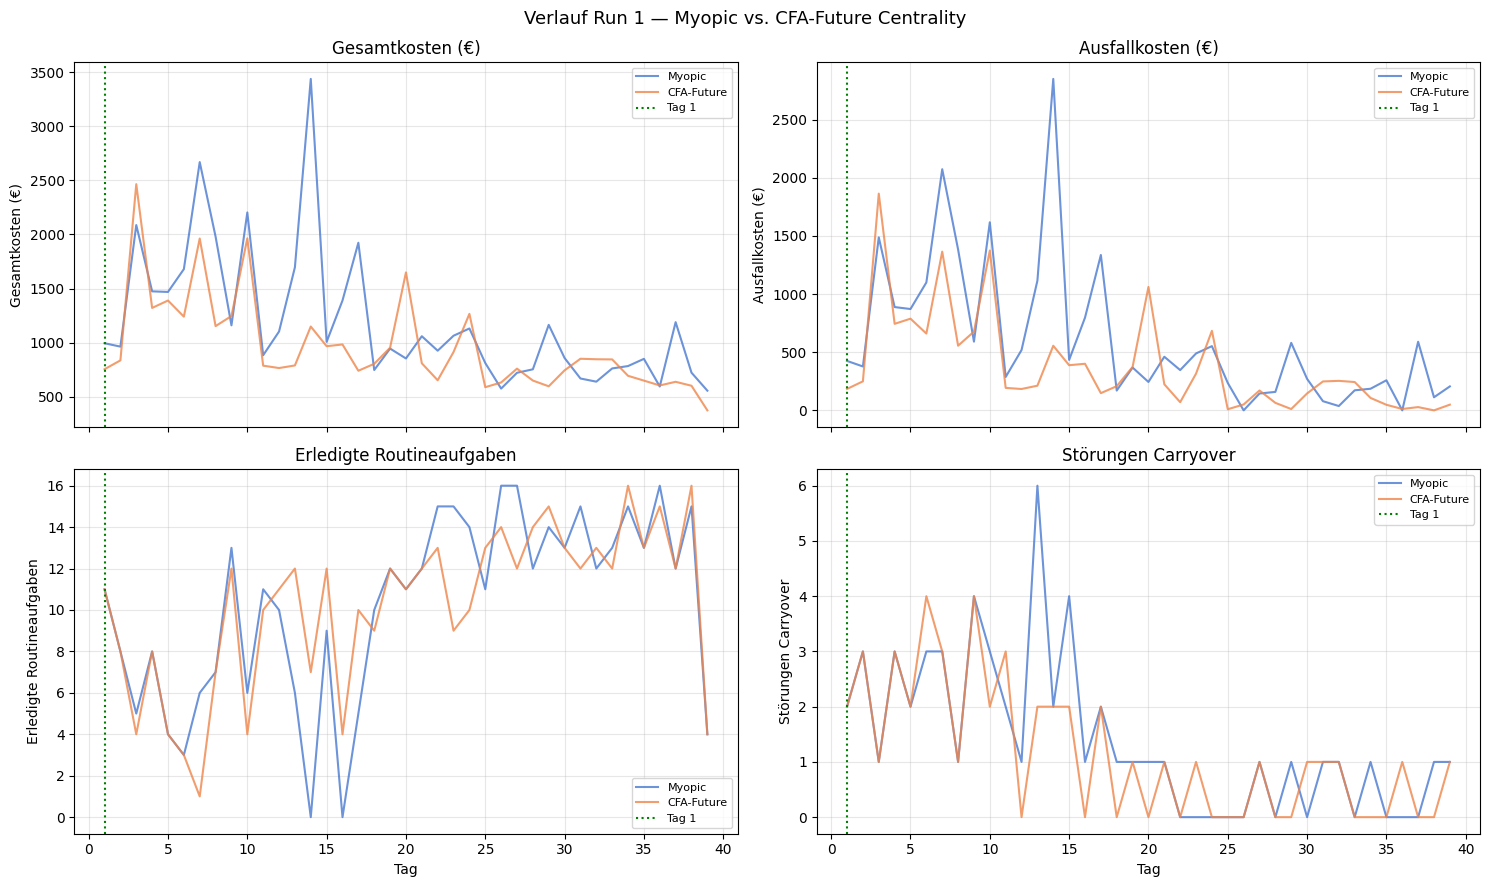

Kumulative Gesamtkosten:
  Myopic:     46519.3 €
  CFA-Future: 37660.8 €


In [65]:
def days_to_df(run_json, label):
    rows = []
    for d in run_json['days']:
        rows.append({
            'day': d['day'],
            'total_cost': d['total_cost_eur'],
            'downtime_cost': d['downtime_cost_eur'],
            'operational_cost': d['operational_cost_eur'],
            'n_routine_tasks': d['n_routine_tasks'],
            'n_completed': d['n_routine_completed'],
            'carryover': d['disruptions_carryover'],
            'model': label,
        })
    return pd.DataFrame(rows)

dm_all = days_to_df(myopic, 'Myopic')
dc_all = days_to_df(cfa, 'CFA-Future')

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)

plots = [
    ('total_cost', 'Gesamtkosten (€)', axes[0][0]),
    ('downtime_cost', 'Ausfallkosten (€)', axes[0][1]),
    ('n_completed', 'Erledigte Routineaufgaben', axes[1][0]),
    ('carryover', 'Störungen Carryover', axes[1][1]),
]

for col, label, ax in plots:
    ax.plot(dm_all['day'], dm_all[col], label='Myopic', color='#4878d0', alpha=0.8, lw=1.5)
    ax.plot(dc_all['day'], dc_all[col], label='CFA-Future', color='#ee854a', alpha=0.8, lw=1.5)
    ax.axvline(1, color='green', linestyle=':', lw=1.5, label='Tag 1')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel('Tag')

fig.suptitle('Verlauf Run 1 — Myopic vs. CFA-Future Centrality', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Kumulative Gesamtkosten:")
print(f"  Myopic:     {dm_all['total_cost'].sum():.1f} €")
print(f"  CFA-Future: {dc_all['total_cost'].sum():.1f} €")